<a href="https://colab.research.google.com/github/souptikmaiti/building-llm/blob/main/004_Position_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### POSITIONAL EMBEDDINGS (ENCODING WORD POSITIONS)

Previously, we focused on very small embedding sizes in this chapter for illustration
purposes.

We now consider more realistic and useful embedding sizes and encode the input
tokens into a 256-dimensional vector representation.

This is smaller than what the original
GPT-3 model used (in GPT-3, the embedding size is 12,288 dimensions) but still reasonable
for experimentation.

Furthermore, we assume that the token IDs were created by the BPE
tokenizer that we implemented earlier, which has a vocabulary size of 50,257:

In [ ]:
import torch

In [ ]:
vocab_size = 50257
embedding_dim = 256

token_embedding_layer = torch.nn.Embedding(vocab_size, embedding_dim)

Using the token_embedding_layer above, if we sample data from the data loader, we
embed each token in each batch into a 256-dimensional vector. If we have a batch size of 8
with four tokens each, the result will be an 8 x 4 x 256 tensor.

In [ ]:
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):
  def __init__(self, txt, tokenizer, max_length, stride):
    # max_length is the context size -> here window size
    # stride is -> by which we slide the window in next iter of for loop
    self.input_ids = []
    self.target_ids = []

    # Tokenize the entire text
    token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

    # Use sliding window to chunk the book into overlapping seq of max_length
    for i in range(0, len(token_ids) - max_length, stride):
      input_chunk = token_ids[i : i + max_length]
      target_chunk = token_ids[i + 1 : i + max_length + 1]
      self.input_ids.append(torch.tensor(input_chunk))
      self.target_ids.append(torch.tensor(target_chunk))

  def __len__(self):
    return len(self.input_ids)

  def __getitem__(self, idx):
    return self.input_ids[idx], self.target_ids[idx]


In [ ]:
!pip install -q tiktoken

In [ ]:
import tiktoken

In [ ]:
def create_data_loader_v1(txt, batch_size=4, max_length=256,
                          stride=128, shuffle=True, drop_last=True,
                          num_workers=0):
  # batch_size -> no. of batches the model processes at once before updating its parameters
  # num_workers -> parallel proceesing, depends on no. of cpu

  # Intitialize the tokenizer
  tokenizer = tiktoken.get_encoding("gpt2")

  # Create dataset
  dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

  # Create dataloader
  dataloader = DataLoader(
      dataset=dataset,
      batch_size=batch_size,
      shuffle=shuffle,
      drop_last=drop_last,
      num_workers=num_workers
  )
  return dataloader

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
verdict_book_path = "/content/drive/MyDrive/building_llms/the-verdict.txt"

Mounted at /content/drive


In [ ]:
with open(verdict_book_path, "r", encoding="utf-8") as f:
  raw_text = f.read()

In [ ]:
max_length = 4 # context size
dataloader = create_data_loader_v1(
    txt=raw_text,
    batch_size=8, max_length=max_length, stride=max_length, shuffle=False
)
data_iter = iter(dataloader)
inputs,targets = next(data_iter)


In [ ]:
print("Token IDs:\n", inputs)
print("\nInput Shape:\n", inputs.shape)

Token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Input Shape:
 torch.Size([8, 4])


As we can see, the token ID tensor is 8x4-dimensional, meaning that the data batch
consists of 8 text samples with 4 tokens each.

In [ ]:
token_embeddings = token_embedding_layer(inputs)
print(token_embeddings.shape)

torch.Size([8, 4, 256])


As we can tell based on the 8x4x256-dimensional tensor output, each token ID is now
embedded as a 256-dimensional vector.

For a GPT model's absolute embedding approach, we just need to create another
embedding layer that has the same dimension as the token_embedding_layer:

In [ ]:
context_length = 4
pos_embedding_layer = torch.nn.Embedding(context_length, embedding_dim) # positional embedding is needed only for 4 (context size) positions
# where as token embedding was for all tokens in the vocab (50257)

In [ ]:
pos_embeddings = pos_embedding_layer(torch.arange(max_length)) # pos_embedding_layer([0,1,2,3])
print(pos_embeddings.shape)

torch.Size([4, 256])


As shown in the preceding code example, the input to the pos_embeddings is usually a
placeholder vector torch.arange(context_length), which contains a sequence of
numbers 0, 1, ..., up to the maximum input length − 1.

The context_length is a variable
that represents the supported input size of the LLM.

Here, we choose it similar to the
maximum length of the input text.

In practice, input text can be longer than the supported
context length, in which case we have to truncate the text.

As we can see, the positional embedding tensor consists of four 256-dimensional vectors.
We can now add these directly to the token embeddings, where PyTorch will add the 4x256-
dimensional pos_embeddings tensor to each 4x256-dimensional token embedding tensor in
each of the 8 batches:

In [ ]:
# broadcasting happens (8x4x256) + (4x256) -> (4x256) pos_emb got replicated for all 8 rows in the batch
input_embeddings = token_embeddings + pos_embeddings
print(input_embeddings.shape)

torch.Size([8, 4, 256])


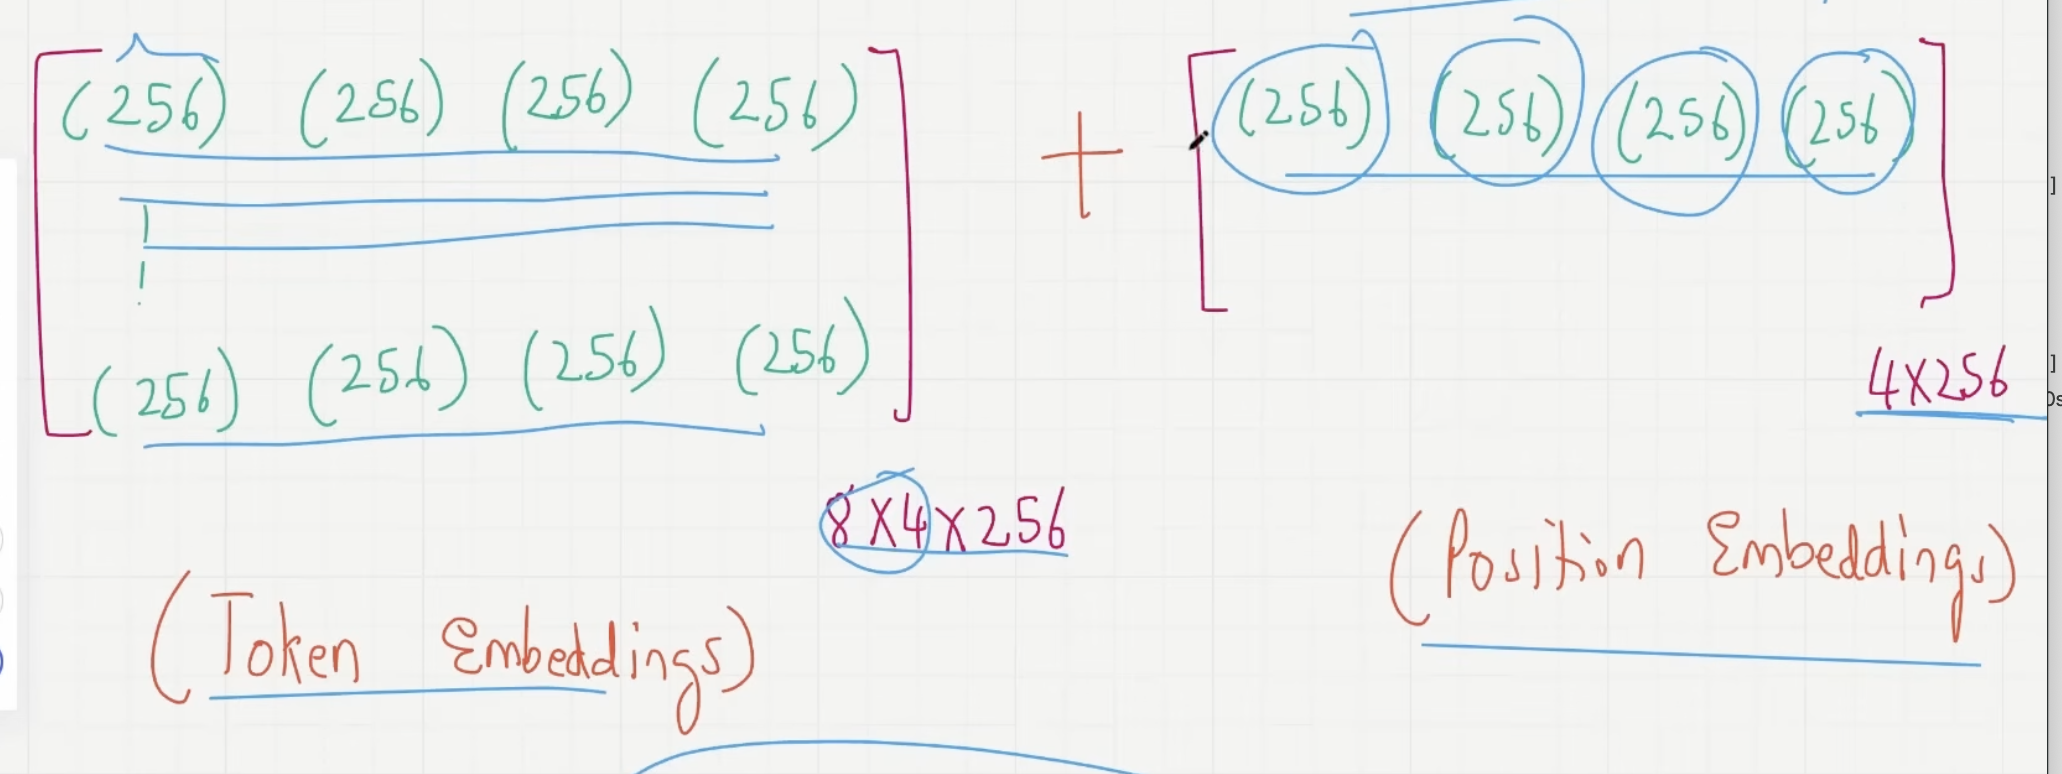


The input_embeddings we created are the embedded input
examples that can now be processed by the main LLM modules